🌐 Communication Round 1/15
✅ Validation Accuracy: 85.03%
🌐 Communication Round 2/15
✅ Validation Accuracy: 88.14%
🌐 Communication Round 3/15
✅ Validation Accuracy: 90.06%
🌐 Communication Round 4/15
✅ Validation Accuracy: 92.19%
🌐 Communication Round 5/15
✅ Validation Accuracy: 93.65%
🌐 Communication Round 6/15
✅ Validation Accuracy: 94.17%
🌐 Communication Round 7/15
✅ Validation Accuracy: 95.06%
🌐 Communication Round 8/15
✅ Validation Accuracy: 95.71%
🌐 Communication Round 9/15
✅ Validation Accuracy: 95.9%
🌐 Communication Round 10/15
✅ Validation Accuracy: 95.98%
🌐 Communication Round 11/15
✅ Validation Accuracy: 95.95%
🌐 Communication Round 12/15
✅ Validation Accuracy: 95.97%
🌐 Communication Round 13/15
✅ Validation Accuracy: 95.94%
🌐 Communication Round 14/15
✅ Validation Accuracy: 95.35%
🌐 Communication Round 15/15
✅ Validation Accuracy: 95.36%

🎯 Final Test Accuracy (WOA/BAT - Dry Run): 95.36%


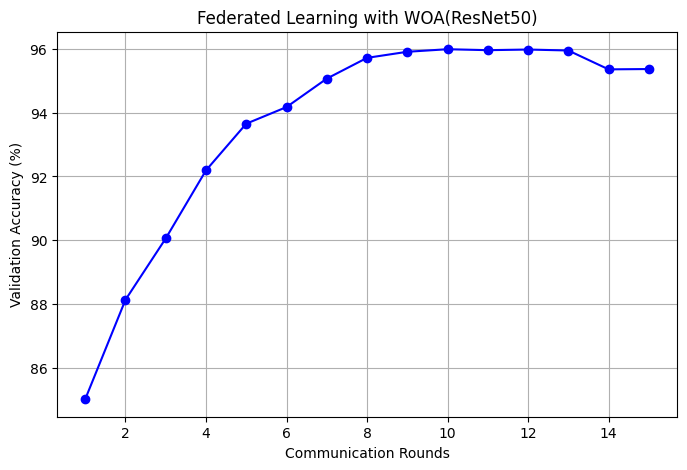

In [ ]:
# =========================================================
# FEDERATED LEARNING + RESNET50 + WHALE OPTIMIZATION (WOA)
# =========================================================

# -------------------- DRIVE --------------------
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score

# ===================== DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== PATHS ======================
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"

train_dir = os.path.join(BASE_PATH, "train_set")
val_dir   = os.path.join(BASE_PATH, "validation_set")
test_dir  = os.path.join(BASE_PATH, "test_set")

# ================== FL PARAMETERS =================
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLIENTS = 5
COMM_ROUNDS = 10
LOCAL_EPOCHS = 1

# ================== WOA PARAMETERS =================
NUM_WHALES = 8
A_MAX = 2.0
A_MIN = 0.0
SPIRAL_B = 1.0
INIT_STD = 0.02

# ===================== TRANSFORMS =====================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ===================== DATASETS =====================
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

# ===================== FL SPLIT =====================
dataset_size = len(train_dataset)
client_len = dataset_size // NUM_CLIENTS
remainder = dataset_size % NUM_CLIENTS

client_sizes = [client_len] * NUM_CLIENTS
client_sizes[-1] += remainder

client_datasets = random_split(train_dataset, client_sizes)

client_loaders = [
    DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    for ds in client_datasets
]

val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===================== MODEL =====================
def get_resnet50():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)

# ===================== LOSS =====================
criterion = nn.CrossEntropyLoss()

# ===================== FITNESS FUNCTION =====================
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = torch.argmax(out, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    return accuracy_score(y_true, y_pred)

# ===================== LOCAL TRAIN =====================
def local_train(model, loader):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for _ in range(LOCAL_EPOCHS):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

# ===================== WOA UPDATE =====================
def whale_update(global_weights, whales, a):
    new_whales = []

    for whale in whales:
        r1, r2 = random.random(), random.random()
        A = 2 * a * r1 - a
        C = 2 * r2
        p = random.random()

        new_whale = {}

        for k in global_weights.keys():
            # Check if the tensor is a floating-point parameter
            # Buffers like 'num_batches_tracked' are typically Long tensors and should not be perturbed with random floats
            if global_weights[k].is_floating_point():
                D = abs(C * global_weights[k] - whale[k])

                if p < 0.5:
                    new_whale[k] = global_weights[k] - A * D
                else:
                    l = random.uniform(-1, 1)
                    new_whale[k] = (
                        D * math.exp(SPIRAL_B * l)
                        * math.cos(2 * math.pi * l)
                        + global_weights[k]
                    )
            else: # Keep non-floating point parameters (buffers) as they are
                new_whale[k] = global_weights[k]

        new_whales.append(new_whale)

    return new_whales

# ===================== INITIALIZE GLOBAL MODEL =====================
global_model = get_resnet50()
global_weights = copy.deepcopy(global_model.state_dict())

# ===================== INITIALIZE WHALES =====================
whales = []
for _ in range(NUM_WHALES):
    whale = {}
    for k, v in global_weights.items():
        # Only add noise to floating-point parameters (weights/biases)
        # Skip non-floating point parameters (buffers like num_batches_tracked)
        if v.is_floating_point():
            whale[k] = v + INIT_STD * torch.randn_like(v)
        else:
            whale[k] = v # Keep buffers as is
    whales.append(whale)

# ===================== FEDERATED TRAINING =====================
round_acc = []

for rnd in range(COMM_ROUNDS):
    print(f"\n\uD83C\uDF10 Communication Round {rnd+1}/{COMM_ROUNDS}")

    a = A_MAX - rnd * ((A_MAX - A_MIN) / COMM_ROUNDS)

    client_models = []

    for cid in range(NUM_CLIENTS):
        local_model = get_resnet50()
        local_model.load_state_dict(global_weights)

        local_train(local_model, client_loaders[cid])
        client_models.append(copy.deepcopy(local_model.state_dict()))

    # FedAvg
    new_global = copy.deepcopy(global_weights)
    for k in new_global.keys():
        new_global[k] = torch.stack([cm[k] for cm in client_models]).mean(dim=0)

    # WOA refinement
    whales = whale_update(new_global, whales, a)

    # Select best whale
    best_acc = 0
    best_weights = None

    for whale in whales:
        temp_model = get_resnet50()
        temp_model.load_state_dict(whale)
        acc = evaluate_model(temp_model, val_loader)

        if acc > best_acc:
            best_acc = acc
            best_weights = whale

    global_weights = copy.deepcopy(best_weights)
    global_model.load_state_dict(global_weights)

    print(f"\u2705 Validation Accuracy: {best_acc*100:.2f}%")
    round_acc.append(best_acc)

# ===================== TEST =====================
test_acc = evaluate_model(global_model, test_loader)
print(f"\n\uD83C\uDFAF Final Test Accuracy (WOA): {test_acc*100:.2f}%")

# ===================== PLOT =====================
plt.figure()
plt.plot(range(1, COMM_ROUNDS+1), round_acc, marker='o')
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy")
plt.title("Federated Learning with WOA(ResNet50)")
plt.grid()
plt.show()

Confusion Matrix (WHALE):
[[1258   60]
 [  14  268]]


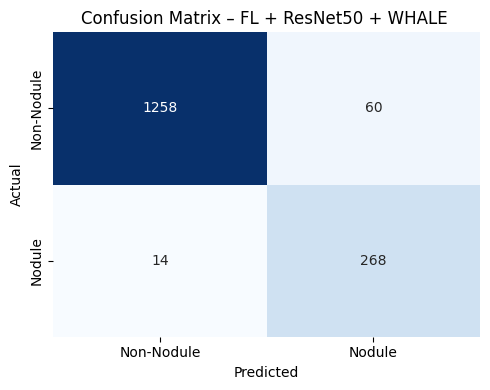


Metrics for WHALE Optimizer:
Accuracy    : 95.38%
Sensitivity : 95.04%
Specificity : 95.45%


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
def evaluate_confusion_matrix(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\n========== CONFUSION MATRIX (FL + WOA) ==========")
    print(cm)

    print("\n========== CLASSIFICATION REPORT ==========")
    print(classification_report(
        y_true, y_pred,
        target_names=["Non-Nodule", "Nodule"]
    ))

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Nodule", "Nodule"],
        yticklabels=["Non-Nodule", "Nodule"],
        cbar=False
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix – FL + WOA")
    plt.tight_layout()
    plt.show()
